# 05 - Modèle SVM

## Introduction

Dans ce cinquième notebook du projet **Employee Attrition Prediction - RH**, nous entraînons un modèle **SVM** (*Support Vector Machine*).

SVM est un algorithme de classification supervisée qui cherche à séparer les classes avec une frontière optimale. Dans ce projet, il est utilisé pour prédire si un employé appartient à la classe **Attrition = Yes** ou **Attrition = No**.

Contrairement aux modèles basés sur des arbres, SVM est sensible à l'échelle des variables. C'est pourquoi les variables numériques doivent généralement être standardisées avec `StandardScaler`.

## 1. Importation des bibliothèques

In [1]:
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

In [2]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)

**Interprétation :** Ces bibliothèques permettent de charger les données, de préparer les variables, d'entraîner un modèle SVM, d'évaluer ses performances et de sauvegarder les résultats.

## 2. Chargement du dataset

In [3]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.shape

(1470, 35)

**Interprétation :** Le dataset est rechargé depuis le fichier CSV original. Nous repartons de la même base que les notebooks précédents afin de garder une comparaison cohérente entre les modèles.

## 3. Nettoyage des colonnes non utiles

In [5]:
columns_to_drop = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]

# On supprime seulement les colonnes qui existent dans le dataset.
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_columns_to_drop)

existing_columns_to_drop

['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

**Interprétation :** Ces colonnes sont supprimées car elles sont constantes, identifiantes ou peu utiles pour l'apprentissage. Elles risquent de ne pas apporter d'information générale pour prédire l'attrition.

## 4. Séparation des variables explicatives et de la variable cible

In [6]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"].map({"Yes": 1, "No": 0})

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)
print("Distribution de la cible :")
print(y.value_counts())

Dimensions de X : (1470, 30)
Dimensions de y : (1470,)
Distribution de la cible :
Attrition
0    1233
1     237
Name: count, dtype: int64


**Interprétation :** `Attrition` est la variable cible à prédire. Elle est transformée en variable numérique : `Yes = 1` signifie que l'employé quitte l'entreprise, et `No = 0` signifie qu'il reste.

## 5. Identification des variables numériques et catégorielles

In [7]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Nombre de variables numériques : {len(numeric_features)}")
print(numeric_features)

print(f"\nNombre de variables catégorielles : {len(categorical_features)}")
print(categorical_features)

Nombre de variables numériques : 23
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Nombre de variables catégorielles : 7
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


**Interprétation :** Les variables catégorielles doivent être transformées en valeurs numériques avec un encodage. Les variables numériques doivent aussi être mises à l'échelle, car SVM est sensible aux différences d'unités et d'amplitudes entre les variables.

## 6. Création du préprocesseur pour SVM

In [8]:
preprocessor_svm = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

preprocessor_svm

ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                 ['Age', 'DailyRate', 'DistanceFromHome',
                                  'Education', 'EnvironmentSatisfaction',
                                  'HourlyRate', 'JobInvolvement', 'JobLevel',
                                  'JobSatisfaction', 'MonthlyIncome',
                                  'MonthlyRate', 'NumCompaniesWorked',
                                  'PercentSalaryHike', 'PerformanceRating',
                                  'RelationshipSatisfaction',
                                  'StockOptionLevel', 'TotalWorkingYears',
                                  'TrainingTimesLastYear', 'WorkLifeBalance',
                                  'YearsAtCompany', 'YearsInCurrentRole',
                                  'YearsSinceLastPromotion',
                                  'YearsWithCurrManager']),
                                ('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['BusinessTravel', 'Department',
                                  'EducationField', 'Gender', 'JobRole',
                                  'MaritalStatus', 'OverTime'])])

**Interprétation :** SVM est sensible à l'échelle des variables. `StandardScaler` permet de mettre les variables numériques sur une même échelle, tandis que `OneHotEncoder` transforme les variables catégorielles en variables numériques.

## 7. Séparation train/test

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (1176, 30)
X_test : (294, 30)
y_train : (1176,)
y_test : (294,)


In [10]:
print("Distribution de y_train :")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribution de y_test :")
print(y_test.value_counts(normalize=True) * 100)

Distribution de y_train :
Attrition
0    83.843537
1    16.156463
Name: proportion, dtype: float64

Distribution de y_test :
Attrition
0    84.013605
1    15.986395
Name: proportion, dtype: float64


## 8. Modèle SVM baseline

In [11]:
svm_model_baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_svm),
        ("classifier", SVC(
            kernel="rbf",
            random_state=42,
        )),
    ]
)

svm_model_baseline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'Stoc...onLevel',
                                                   'TotalWorkingYears',
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier', SVC(random_state=42))])

**Interprétation :** Ce pipeline contient le prétraitement spécifique à SVM et le modèle SVM baseline avec un noyau RBF. Ce modèle servira de point de départ pour la comparaison.

## 9. Entraînement du modèle baseline

In [12]:
svm_model_baseline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'Stoc...onLevel',
                                                   'TotalWorkingYears',
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier', SVC(random_state=42))])

**Interprétation :** Le modèle apprend à partir des données d'entraînement. Grâce au préprocesseur, les variables numériques sont standardisées avant l'entraînement.

## 10. Prédictions du modèle baseline

In [13]:
y_pred_svm_baseline = svm_model_baseline.predict(X_test)
y_pred_svm_baseline[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

**Interprétation :** Les prédictions sont faites sur les données de test. Ces données n'ont pas été utilisées pendant l'entraînement, ce qui permet d'évaluer la généralisation du modèle.

## 11. Évaluation du modèle baseline

In [14]:
accuracy_svm_baseline = accuracy_score(y_test, y_pred_svm_baseline)
precision_svm_baseline = precision_score(y_test, y_pred_svm_baseline, zero_division=0)
recall_svm_baseline = recall_score(y_test, y_pred_svm_baseline, zero_division=0)
f1_svm_baseline = f1_score(y_test, y_pred_svm_baseline, zero_division=0)

metrics_svm_baseline_df = pd.DataFrame(
    {
        "model": ["SVM Baseline"],
        "accuracy": [accuracy_svm_baseline],
        "precision": [precision_svm_baseline],
        "recall": [recall_svm_baseline],
        "f1_score": [f1_svm_baseline],
    }
)

metrics_svm_baseline_df

,model,accuracy,precision,recall,f1_score
0,SVM Baseline,0.860544,0.75,0.191489,0.305085


**Interprétation :**

On remarque que le modèle SVM Baseline obtient une accuracy de 0,8605, soit environ 86,05 %.

Cela veut dire que le modèle prédit correctement une grande partie des employés.
À première vue, ce score semble bon.

Mais il ne faut pas se baser seulement sur l’accuracy, car dans ce projet les classes sont déséquilibrées.
Il y a plus d’employés qui restent dans l’entreprise que d’employés qui la quittent.

La précision est de 0,75, soit 75 %.
Cela signifie que lorsque le modèle prédit qu’un employé risque de quitter l’entreprise, il a souvent raison.

Par contre, le recall est de 0,1915, soit environ 19,15 %.
Cela veut dire que le modèle détecte seulement une petite partie des employés qui ont réellement quitté l’entreprise.
Il rate donc beaucoup d’employés à risque.

Le F1-score est de 0,3051, soit environ 30,51 %.
Ce score reste faible, car le recall est très bas.
Cela montre que le modèle n’est pas encore assez efficace pour détecter la classe importante Attrition = Yes.

Même si le SVM Baseline donne une bonne accuracy et une bonne précision, il détecte mal les employés en attrition.

In [15]:
print(classification_report(y_test, y_pred_svm_baseline, target_names=["No", "Yes"]))

              precision    recall  f1-score   support

          No       0.87      0.99      0.92       247
         Yes       0.75      0.19      0.31        47

    accuracy                           0.86       294
   macro avg       0.81      0.59      0.61       294
weighted avg       0.85      0.86      0.82       294



**Interprétation :** On remarque que le modèle SVM Baseline obtient une accuracy globale de 0,86, soit environ 86 %.

Cela veut dire que le modèle prédit correctement une grande partie des employés.
Mais il faut faire attention, car les classes sont déséquilibrées : il y a 247 employés dans la classe No, contre seulement 47 employés dans la classe Yes.

Pour la classe No, les résultats sont très bons.
La précision est de 0,87, le recall est de 0,99 et le F1-score est de 0,92.
Cela signifie que le modèle reconnaît très bien les employés qui ne quittent pas l’entreprise.

Par contre, pour la classe Yes, les résultats sont plus faibles.
La précision est de 0,75, donc quand le modèle prédit qu’un employé va quitter l’entreprise, il a souvent raison.

Mais le recall est seulement de 0,19.
Cela signifie que le modèle détecte seulement 19 % des employés qui ont réellement quitté l’entreprise.
Il rate donc beaucoup d’employés à risque.

Le F1-score de la classe Yes est de 0,31.
Ce score reste faible, car le modèle n’arrive pas à bien détecter la classe importante Attrition = Yes.

Même si le SVM Baseline donne une bonne accuracy, il est surtout performant pour la classe majoritaire No.

## 12. Matrice de confusion baseline

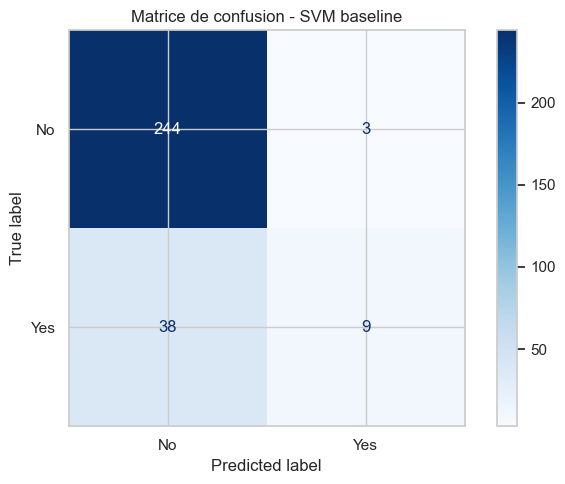

In [16]:
cm_svm_baseline = confusion_matrix(y_test, y_pred_svm_baseline)

disp_svm_baseline = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm_baseline,
    display_labels=["No", "Yes"],
)

fig, ax = plt.subplots(figsize=(7, 5))
disp_svm_baseline.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Matrice de confusion - SVM baseline")
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix_svm_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** On remarque que la matrice de confusion du SVM Baseline montre que le modèle prédit très bien la classe Attrition = No.

Le modèle a correctement prédit 244 employés comme Attrition = No.
Cela veut dire que ces employés ne quittent pas l’entreprise, et le modèle les a bien classés.

Le modèle a aussi correctement prédit seulement 9 employés comme Attrition = Yes.
Cela veut dire que le modèle arrive à détecter quelques employés qui ont réellement quitté l’entreprise, mais ce nombre reste faible.

On remarque aussi que le modèle a prédit 3 employés comme Attrition = Yes, alors qu’ils sont réellement No.
Ce sont des fausses alertes.
Le nombre est très faible, donc le modèle ne fait presque pas de fausses alertes.

Par contre, le modèle a prédit 38 employés comme Attrition = No, alors qu’ils sont réellement Yes.
Cela veut dire que le modèle a raté 38 employés qui ont réellement quitté l’entreprise.

Même si le SVM Baseline prédit très bien les employés qui restent, il détecte mal les employés qui risquent de quitter l’entreprise.

La matrice confirme aussi que l’accuracy peut être trompeuse.
Le modèle semble performant parce qu’il prédit très bien la classe majoritaire No, mais il rate beaucoup de cas importants dans la classe Yes.

## 13. Amélioration du modèle SVM

Le modèle SVM baseline peut être influencé par le déséquilibre des classes. Comme **Attrition = Yes** est minoritaire, nous testons une version améliorée avec `class_weight="balanced"`.

Cette option donne plus de poids à la classe minoritaire pendant l'apprentissage, ce qui peut aider le modèle à mieux détecter les employés qui quittent l'entreprise.

In [17]:
svm_model_improved = Pipeline(
    steps=[
        ("preprocessor", preprocessor_svm),
        ("classifier", SVC(
            kernel="rbf",
            class_weight="balanced",
            C=1.0,
            gamma="scale",
            random_state=42,
        )),
    ]
)

svm_model_improved

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'Stoc...
                                                   'TotalWorkingYears',
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier', SVC(class_weight='balanced', random_state=42))])

Cette version utilise toujours un noyau RBF, mais ajoute `class_weight="balanced"` pour mieux prendre en compte la classe minoritaire. Les paramètres `C=1.0` et `gamma="scale"` sont des paramètres standards pour commencer.

## 14. Entraînement et prédictions du modèle amélioré

In [18]:
svm_model_improved.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'Stoc...
                                                   'TotalWorkingYears',
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier', SVC(class_weight='balanced', random_state=42))])

In [19]:
y_pred_svm_improved = svm_model_improved.predict(X_test)
y_pred_svm_improved[:10]

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 1])

Le modèle amélioré est entraîné sur les mêmes données que le modèle baseline, puis testé sur le même ensemble de test. Cela permet une comparaison correcte entre les deux versions.

## 15. Évaluation du modèle amélioré

In [20]:
accuracy_svm_improved = accuracy_score(y_test, y_pred_svm_improved)
precision_svm_improved = precision_score(y_test, y_pred_svm_improved, zero_division=0)
recall_svm_improved = recall_score(y_test, y_pred_svm_improved, zero_division=0)
f1_svm_improved = f1_score(y_test, y_pred_svm_improved, zero_division=0)

metrics_svm_improved_df = pd.DataFrame(
    {
        "model": ["SVM Improved"],
        "accuracy": [accuracy_svm_improved],
        "precision": [precision_svm_improved],
        "recall": [recall_svm_improved],
        "f1_score": [f1_svm_improved],
    }
)

metrics_svm_improved_df

,model,accuracy,precision,recall,f1_score
0,SVM Improved,0.833333,0.483333,0.617021,0.542056


**Interprétation :** On remarque que le modèle SVM Improved obtient une accuracy de 0,8333, soit environ 83,33 %.

Cela veut dire que le modèle prédit correctement une grande partie des employés.
L’accuracy reste bonne, même si elle est un peu plus faible que celle du SVM baseline.

La précision est de 0,4833, soit environ 48,33 %.
Cela signifie que, parmi les employés prédits comme Attrition = Yes, presque la moitié ont réellement quitté l’entreprise.

Le recall est de 0,6170, soit environ 61,70 %.
C’est le résultat le plus important ici.
Cela veut dire que le modèle arrive à détecter plus de la moitié des employés qui ont réellement quitté l’entreprise.

Le F1-score est de 0,5421, soit environ 54,21 %.
Cela montre que le modèle amélioré a un meilleur équilibre entre la précision et le recall.

Même si l’accuracy diminue un peu, le modèle devient plus utile car il détecte beaucoup mieux la classe Attrition = Yes.

In [21]:
print(classification_report(y_test, y_pred_svm_improved, target_names=["No", "Yes"]))

              precision    recall  f1-score   support

          No       0.92      0.87      0.90       247
         Yes       0.48      0.62      0.54        47

    accuracy                           0.83       294
   macro avg       0.70      0.75      0.72       294
weighted avg       0.85      0.83      0.84       294



**Interprétation :** On remarque que le modèle SVM Improved obtient une accuracy globale de 0,83, soit environ 83 %.

Cela veut dire que le modèle prédit correctement une grande partie des employés.
Mais il ne faut pas se baser seulement sur l’accuracy, car les classes sont déséquilibrées.

La classe No contient 247 employés, alors que la classe Yes contient seulement 47 employés.
Cela montre qu’il y a beaucoup plus d’employés qui restent que d’employés qui quittent l’entreprise.

Pour la classe No, le modèle donne de bons résultats.
La précision est de 0,92, le recall est de 0,87 et le F1-score est de 0,90.
Cela signifie que le modèle reconnaît bien les employés qui ne quittent pas l’entreprise.

Pour la classe Yes, les résultats sont plus intéressants que dans le SVM baseline.
La précision est de 0,48.
Cela veut dire que quand le modèle prédit qu’un employé risque de quitter l’entreprise, il a raison presque une fois sur deux.

Le recall de la classe Yes est de 0,62.
C’est un bon point, car cela signifie que le modèle détecte environ 62 % des employés qui ont réellement quitté l’entreprise.

Le F1-score de la classe Yes est de 0,54.
Cela montre que le modèle amélioré a un meilleur équilibre entre la précision et le recall pour détecter l’attrition.

Même si l’accuracy est un peu plus faible que celle du SVM baseline, le modèle amélioré détecte beaucoup mieux la classe importante Attrition = Yes.

## 16. Matrice de confusion du modèle amélioré

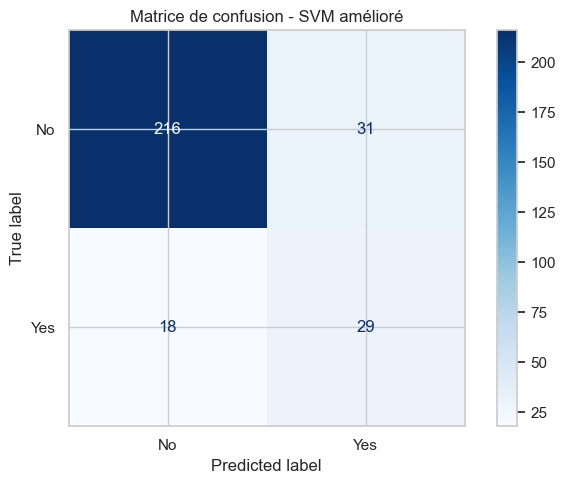

In [22]:
cm_svm_improved = confusion_matrix(y_test, y_pred_svm_improved)

disp_svm_improved = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm_improved,
    display_labels=["No", "Yes"],
)

fig, ax = plt.subplots(figsize=(7, 5))
disp_svm_improved.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Matrice de confusion - SVM amélioré")
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix_svm_improved.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** On remarque que la matrice de confusion du SVM Improved montre une meilleure détection de la classe Attrition = Yes.

Le modèle a correctement prédit 216 employés comme Attrition = No.
Cela veut dire que ces employés ne quittent pas l’entreprise, et le modèle les a bien classés.

Le modèle a aussi correctement prédit 29 employés comme Attrition = Yes.
Cela signifie que le modèle a réussi à détecter 29 employés qui ont réellement quitté l’entreprise.

Par contre, le modèle a prédit 31 employés comme Attrition = Yes, alors qu’ils sont réellement No.
Ce sont des fausses alertes.
Cela veut dire que le modèle pense que certains employés vont quitter l’entreprise, alors qu’ils restent finalement.

Le modèle a aussi prédit 18 employés comme Attrition = No, alors qu’ils sont réellement Yes.
Cela signifie que le modèle a raté 18 employés qui ont réellement quitté l’entreprise.

Par rapport au SVM baseline, le modèle amélioré détecte beaucoup plus d’employés en attrition : il passe de 9 bonnes prédictions Yes à 29.

Cependant, il fait aussi plus de fausses alertes.
Cela montre que le modèle amélioré est plus sensible à la classe Yes, ce qui est utile dans notre projet.

## 17. Sauvegarde des métriques

In [23]:
metrics_dir = "../results/metrics"
os.makedirs(metrics_dir, exist_ok=True)

metrics_svm_baseline_df.to_csv(f"{metrics_dir}/svm_baseline_metrics.csv", index=False)
metrics_svm_improved_df.to_csv(f"{metrics_dir}/svm_improved_metrics.csv", index=False)

print("Métriques sauvegardées dans ../results/metrics")

Métriques sauvegardées dans ../results/metrics


Les métriques des deux versions du SVM sont sauvegardées dans des fichiers CSV. Elles seront utiles pour la comparaison finale entre tous les modèles.

## 18. Sauvegarde des modèles

In [24]:
models_dir = "../results/models"
os.makedirs(models_dir, exist_ok=True)

joblib.dump(svm_model_baseline, f"{models_dir}/svm_baseline_model.joblib")
joblib.dump(svm_model_improved, f"{models_dir}/svm_improved_model.joblib")

print("Modèles sauvegardés dans ../results/models")

Modèles sauvegardés dans ../results/models


Les pipelines complets sont sauvegardés avec `joblib`. Cela inclut le prétraitement avec `StandardScaler`, l'encodage et le modèle SVM.

## 19. Comparaison baseline vs amélioré

In [25]:
comparison_svm_df = pd.concat(
    [metrics_svm_baseline_df, metrics_svm_improved_df],
    ignore_index=True,
)

comparison_svm_df[["model", "accuracy", "precision", "recall", "f1_score"]]

,model,accuracy,precision,recall,f1_score
0,SVM Baseline,0.860544,0.750000,0.191489,0.305085
1,SVM Improved,0.833333,0.483333,0.617021,0.542056


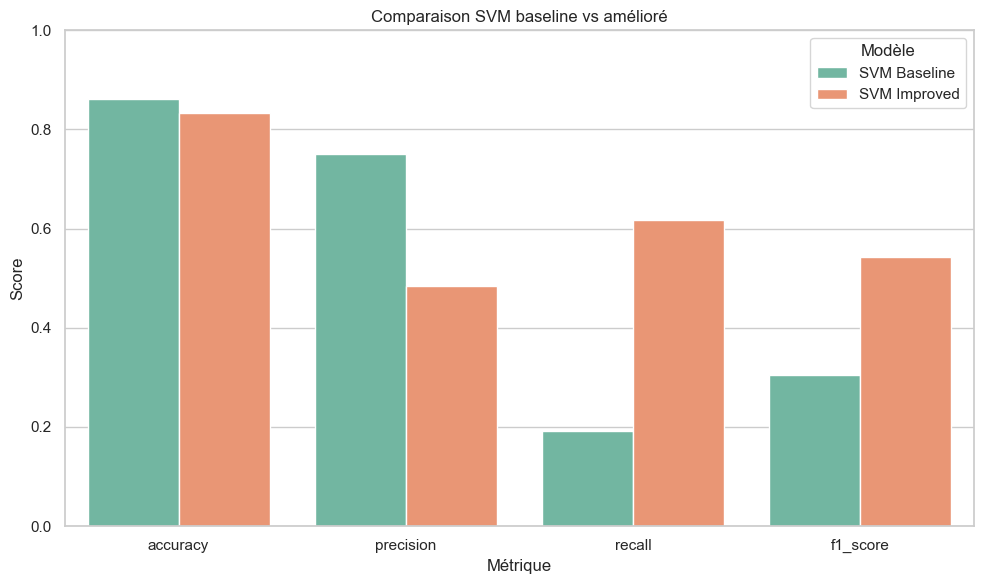

In [26]:
comparison_svm_long = comparison_svm_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1_score"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_svm_long,
    x="metric",
    y="score",
    hue="model",
)
plt.title("Comparaison SVM baseline vs amélioré")
plt.xlabel("Métrique")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Modèle")
plt.tight_layout()
plt.savefig("../results/figures/svm_baseline_vs_improved.png", dpi=300, bbox_inches="tight")
plt.show()

**Interprétation :** On remarque que le SVM Baseline a une accuracy de 0,8605, alors que le SVM Improved a une accuracy de 0,8333.

Cela signifie que le modèle baseline donne une meilleure performance globale.
Mais dans notre projet, l’accuracy seule ne suffit pas, car les classes sont déséquilibrées.

Pour la precision, le SVM Baseline obtient 0,75, alors que le SVM Improved obtient 0,4833.
Cela veut dire que le modèle baseline fait moins de fausses alertes quand il prédit Attrition = Yes.

Par contre, le résultat le plus important est le recall.
Le SVM Baseline a un recall de 0,1915, alors que le SVM Improved atteint 0,6170.

Cela signifie que le SVM Improved détecte beaucoup plus d’employés qui ont réellement quitté l’entreprise.
Il passe d’environ 19 % à environ 62 % de détection pour la classe Yes.

Le F1-score augmente aussi.
Il passe de 0,3051 pour le SVM Baseline à 0,5421 pour le SVM Improved.
Cela montre que le modèle amélioré a un meilleur équilibre entre la precision et le recall.

Même si le SVM Improved perd un peu en accuracy et en precision, il devient plus utile pour détecter les cas Attrition = Yes.

## Conclusion partielle

Dans ce notebook, le modèle **SVM** a été entraîné comme troisième modèle de classification du projet.

Le scaling avec `StandardScaler` est nécessaire pour ce modèle, car SVM est sensible à l'échelle des variables numériques.

La version améliorée avec `class_weight="balanced"` permet de mieux prendre en compte la classe minoritaire **Attrition = Yes**.

Les métriques permettent de comparer SVM aux modèles précédents, notamment **Decision Tree** et **Random Forest**.

La prochaine étape sera la comparaison finale entre **Decision Tree**, **Random Forest** et **SVM**.